In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
data=pd.read_csv('netflix1.csv')
data

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


# Display basic info

In [4]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [5]:
data.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
data.dtypes

show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object

In [7]:
data.shape

(8790, 10)

In [8]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [9]:
data.duplicated().sum()

0

In [10]:
data['date_added']=pd.to_datetime(data['date_added'])

In [11]:
print(data['date_added'].dtype)  # before - likely 'object'

datetime64[ns]


In [12]:
type_counts= data['type'].value_counts()
type_counts

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

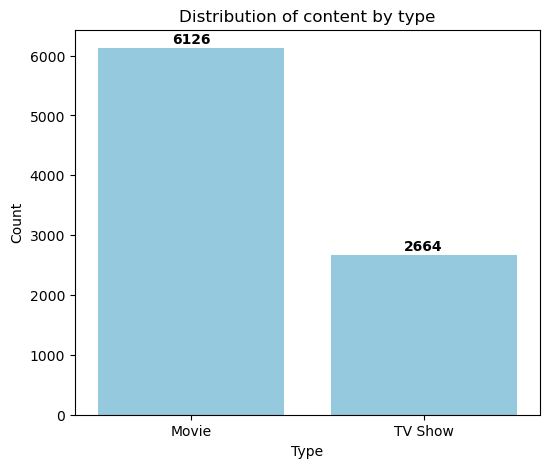

In [13]:
plt.figure(figsize=(6,5))
sns.barplot(x=type_counts.index,y=type_counts.values,color='skyblue')
plt.title('Distribution of content by type')
plt.xlabel('Type')
plt.ylabel('Count')

# Add numbers on top of bars
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 80, str(v), ha='center', fontweight='bold')
#The v + 10 controls how high above the bar the number appears. If it looks too high or too low, just adjust that 10 to a smaller or larger number.
plt.show()

# content rating on netflix

In [14]:
rating_count = data['rating'].value_counts()
rating_count

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

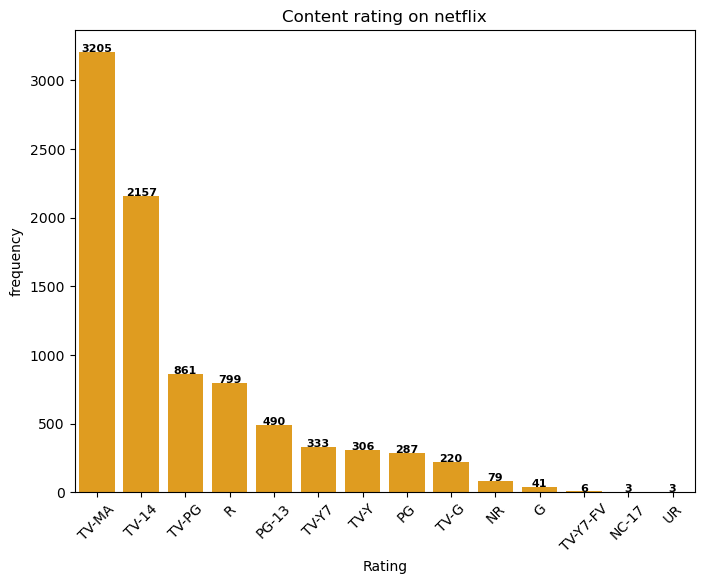

In [15]:
plt.figure(figsize=(8,6))
sns.barplot(x=rating_count.index,y=rating_count.values,color='orange')
plt.title('Content rating on netflix')
plt.xlabel('Rating')
plt.ylabel('frequency')

# Add numbers on top of bars
for i, v in enumerate(rating_count.values):
    plt.text(i, v, str(v), ha='center', fontweight='bold',fontsize=8)
#The v + 10 controls how high above the bar the number appears. If it looks too high or too low, just adjust that 10 to a smaller or larger number.

plt.xticks(rotation=45)
plt.show()

# contents added in each year

In [19]:
#  creating the new column
data['year_added'] = data['date_added'].dt.year

# Then counting how many titles were added each year
yearly_counts = data['year_added'].value_counts().sort_index()
yearly_counts

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

In [20]:
data

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021
...,...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas",2017
8786,s8798,TV Show,Zak Storm,Not Given,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,2018
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",2016
8788,s8784,TV Show,Yoko,Not Given,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV,2018


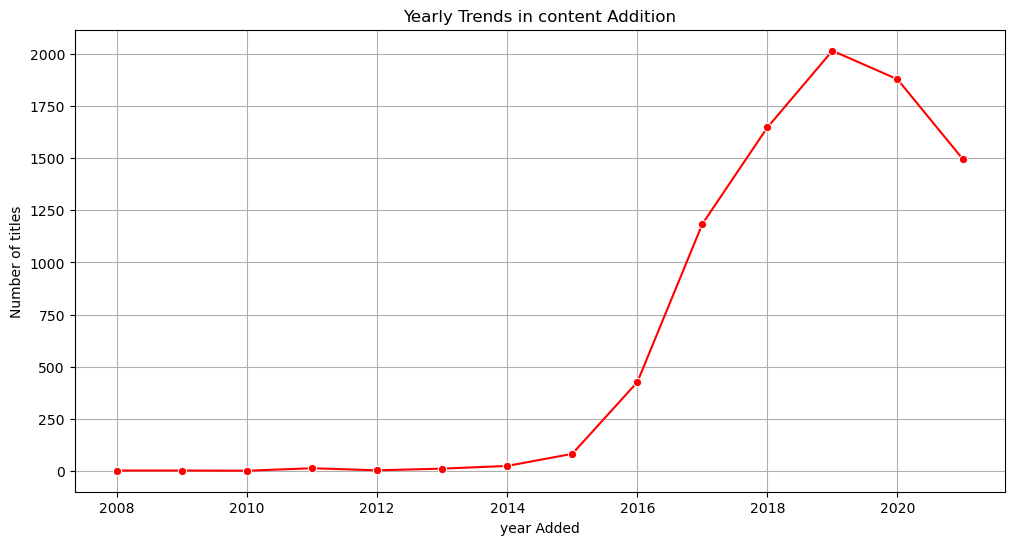

In [22]:
plt.figure(figsize=(12,6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='red')
plt.title('Yearly Trends in content Addition')
plt.xlabel('year Added')
plt.ylabel('Number of titles')
plt.grid(True)
plt.show()

# top 10 most common genres

In [ ]:

data['genres']= data['listed_in'].apply(lambda x: x.split(', ')) #x.split(', ') — cut the string wherever you see ", "
genre_counts= pd.Series(sum(data['genres'], [])).value_counts().head(10)
genre_counts
# we changing each genres in list cause each row has multiple genres...hence we add all in a big list and count

International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [ ]:
# this would also work!
data.explode('genres')['genres'].value_counts().head(10) # from data explode the genres column and pick genres
#() action []selection and calculating on 
# eplode cant work on strings so need lists 

genres
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

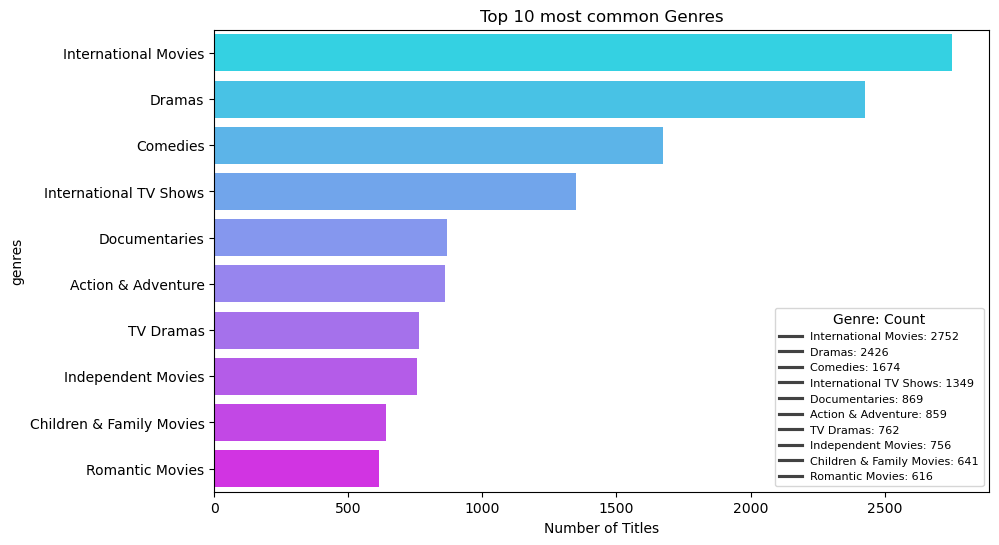

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values,y=genre_counts.index,hue=genre_counts.index,palette='cool')
plt.title('Top 10 most common Genres')
plt.xlabel('Number of Titles')
plt.ylabel('genres')

plt.legend(title='Genre: Count', 
           labels=[f'{genre}: {count}' for genre, count in zip(genre_counts.index, genre_counts.values)],
           loc='lower right',
           fontsize=8)
plt.show()

# find which top 10 countries have the most content on Netflix

In [ ]:

top_countries=data['country'].value_counts().head(10)
top_countries

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

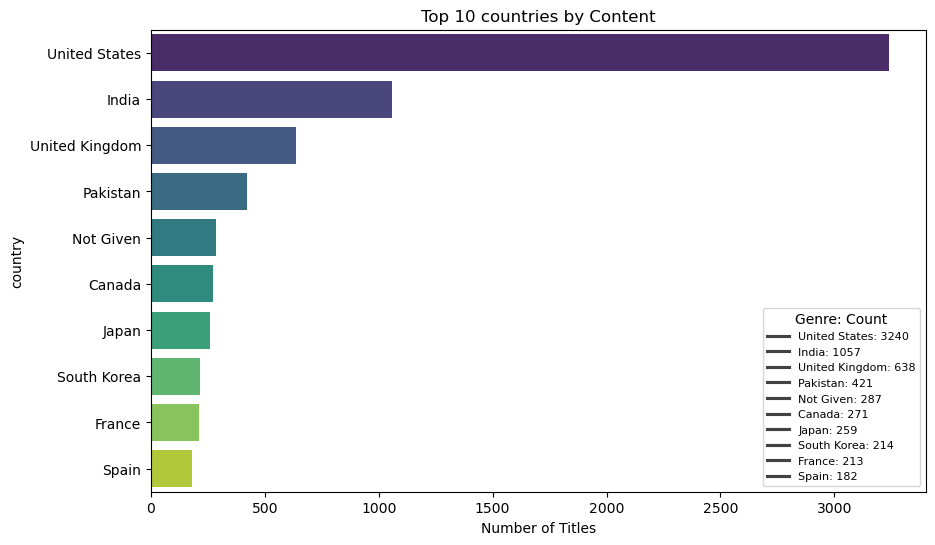

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values,y=top_countries.index,hue=genre_counts.index,palette='viridis')
plt.title('Top 10 countries by Content')
plt.xlabel('Number of Titles')
plt.ylabel('country')

plt.legend(title='Genre: Count', 
           labels=[f'{countries}: {count}' for countries, count in zip(top_countries.index, top_countries.values)],
           loc='lower right',
           fontsize=8)
plt.show()

#  How many titles does each country added in specific year

In [ ]:

data.groupby(['year_added', 'country']).size()[2020].sort_values(ascending=False)
# shows all countries for year 2020 only

country
United States     719
India             197
United Kingdom    106
Japan              68
Canada             64
                 ... 
Jamaica             1
Israel              1
Cyprus              1
Belarus             1
Zimbabwe            1
Length: 64, dtype: int64

In [ ]:
def content_by_year(year):
    result = data.groupby(['year_added', 'country']).size()[year].sort_values(ascending=False).head(10) #[year]means using year to get rows
    #"From all the grouped data, give me only the rows where year = 2020, and show me their countries and counts"
    print(f"\nTop countries that added content in {year}:")
    print(result)

content_by_year(2020)
content_by_year(2019)
content_by_year(2018)



Top countries that added content in 2020:
country
United States     719
India             197
United Kingdom    106
Japan              68
Canada             64
Egypt              53
France             53
Pakistan           50
South Korea        48
Not Given          41
dtype: int64

Top countries that added content in 2019:
country
United States     771
India             222
United Kingdom    158
Pakistan           98
Japan              60
Egypt              59
South Korea        56
Canada             53
France             45
Spain              45
dtype: int64

Top countries that added content in 2018:
country
United States     513
India             339
United Kingdom    119
Pakistan           82
Hong Kong          50
Canada             49
Japan              38
Spain              35
France             34
Thailand           32
dtype: int64



Top 10 countries that added content in 2021:
country
United States     557
Not Given         155
India             135
Pakistan          123
United Kingdom     79
Japan              45
Nigeria            32
France             31
South Korea        30
Canada             27
dtype: int64


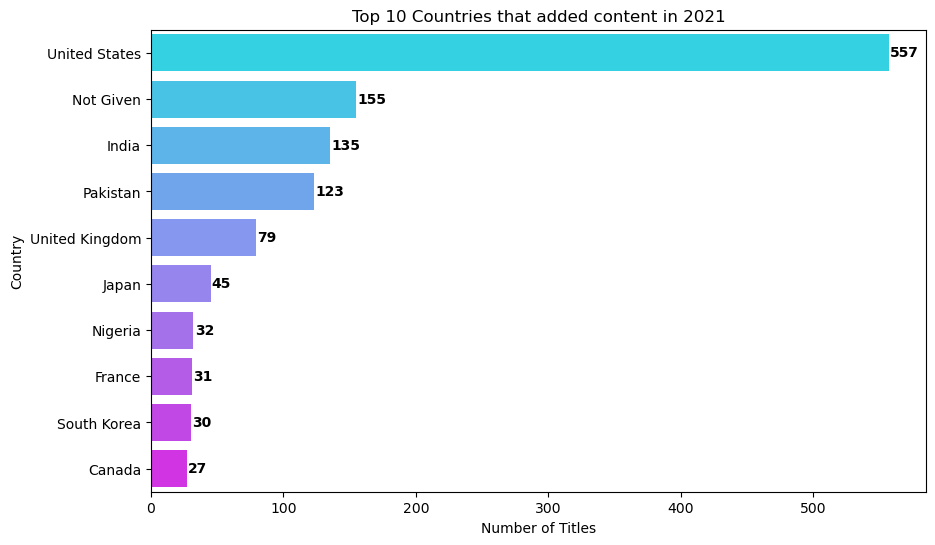


Top 10 countries that added content in 2020:
country
United States     719
India             197
United Kingdom    106
Japan              68
Canada             64
Egypt              53
France             53
Pakistan           50
South Korea        48
Not Given          41
dtype: int64


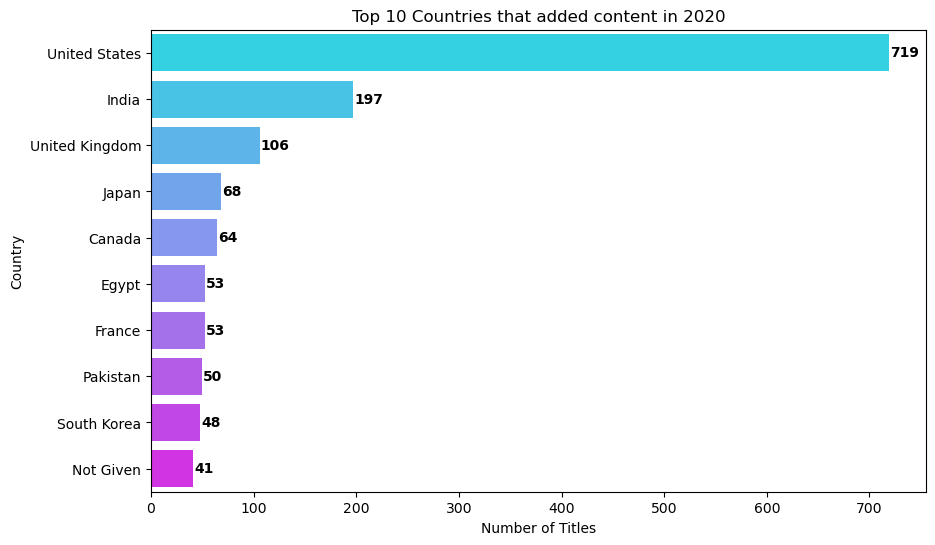


Top 10 countries that added content in 2019:
country
United States     771
India             222
United Kingdom    158
Pakistan           98
Japan              60
Egypt              59
South Korea        56
Canada             53
France             45
Spain              45
dtype: int64


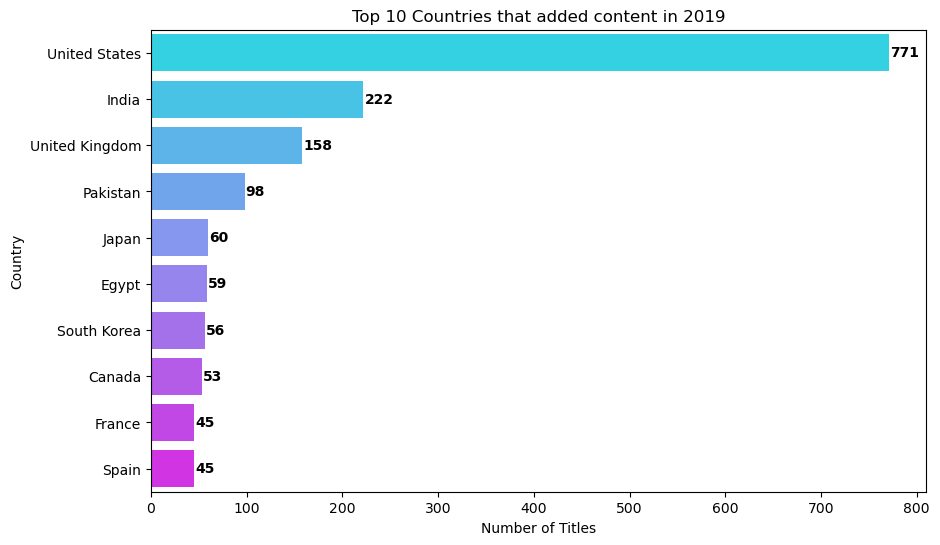

In [55]:
def content_by_year(year):
    result = data.groupby(['year_added', 'country']).size()[year].sort_values(ascending=False).head(10)
    
    print(f"\nTop 10 countries that added content in {year}:")
    print(result)
    
    # plot
    plt.figure(figsize=(10,6))
    sns.barplot(x=result.values, y=result.index,
                hue=result.index, palette='cool', legend=False)
    plt.title(f'Top 10 Countries that added content in {year}')
    plt.xlabel('Number of Titles')
    plt.ylabel('Country')
    
    # add numbers on bars
    for i, v in enumerate(result.values):
        plt.text(v + 1, i, str(v), va='center', fontweight='bold')
    
    plt.show()


content_by_year(2021)
content_by_year(2020)
content_by_year(2019)

# in which month highest content was added

In [35]:
#content adddition moth wise
data['month_added']= data['date_added'].dt.month
monthly_count= data['month_added'].value_counts().sort_index()
monthly_count

month_added
1     737
2     562
3     741
4     763
5     632
6     728
7     827
8     754
9     769
10    760
11    705
12    812
Name: count, dtype: int64

In [36]:
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,genres,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,[Documentaries],9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,"[Crime TV Shows, International TV Shows, TV Ac...",9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,"[TV Dramas, TV Horror, TV Mysteries]",9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,"[Children & Family Movies, Comedies]",9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,"[Dramas, Independent Movies, International Mov...",9


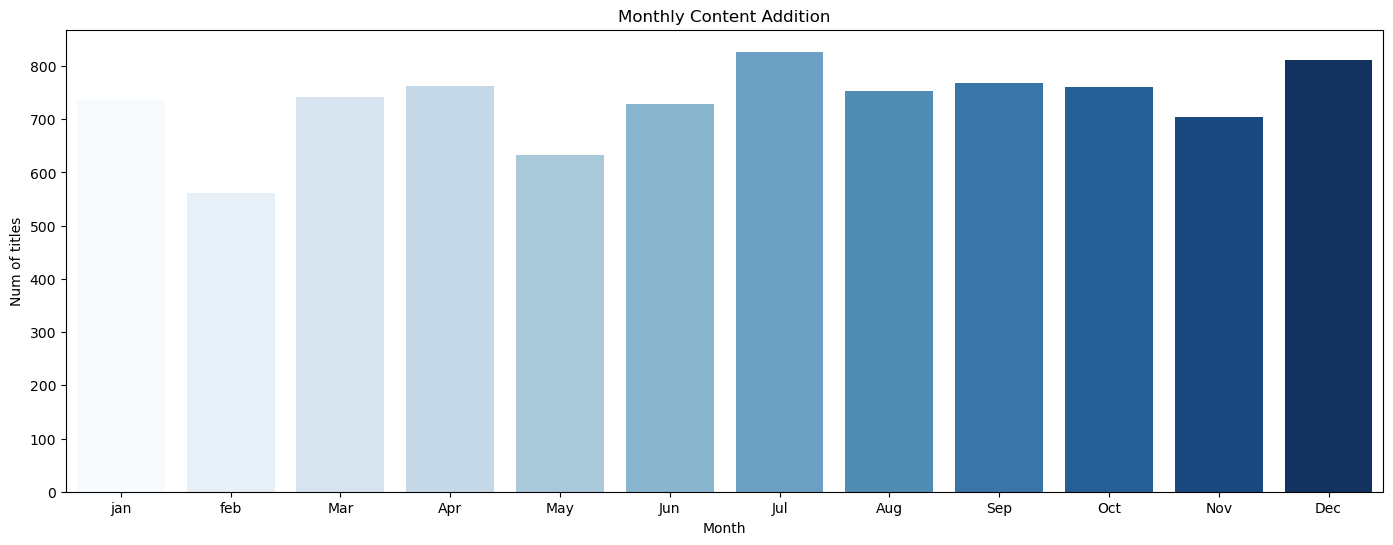

In [68]:
plt.figure(figsize=(17,6))
sns.barplot(x=monthly_count.index, y=monthly_count.values, hue=monthly_count.index, palette='Blues',legend=False)
plt.title('Monthly Content Addition')
plt.xlabel('Month')
plt.ylabel('Num of titles')
plt.xticks(range(0,12),['jan','feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])


plt.show()

In [61]:
data['date_added'].isnull().sum()
# tells you how many dates are missing

0

In [62]:
monthly_count[12]

812

In [65]:
print(monthly_count)

month_added
1     737
2     562
3     741
4     763
5     632
6     728
7     827
8     754
9     769
10    760
11    705
12    812
Name: count, dtype: int64


# Top 10 most title hosting Directors

In [70]:
top_directors= data['director'].value_counts().head(10)
top_directors

director
Not Given                 2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Martin Scorsese             12
Youssef Chahine             12
Name: count, dtype: int64

In [72]:
data['duration_num']= data['duration'].str.extract(r'(\d+)').astype(float)
print(data['duration_num'])

0        90.0
1         1.0
2         1.0
3        91.0
4       125.0
        ...  
8785      2.0
8786      3.0
8787      1.0
8788      1.0
8789      1.0
Name: duration_num, Length: 8790, dtype: float64


In [73]:
movies = data[data['type'] == 'Movie']
movies['duration_num'].describe()

count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64

#  How has Netflix content changed over the years?

Count movies and TV shows separately for each year and put them in a clean table so I can compare them
size() → just count rows  use this for counting titles
count() → count non-null values per column  use this for checking missing data

In [79]:
yearly_type = data.groupby(['year_added', 'type']).size().unstack().fillna(0) #.unstack() Converts long list into a neat table:
yearly_type

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,0.0
2010,1.0,0.0
2011,13.0,0.0
2012,3.0,0.0
2013,6.0,5.0
2014,19.0,5.0
2015,56.0,26.0
2016,251.0,175.0


In [80]:
yearly_type = pd.crosstab(data['year_added'], data['type'])
yearly_type

type,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,5
2014,19,5
2015,56,26
2016,251,175


<Figure size 1200x600 with 0 Axes>

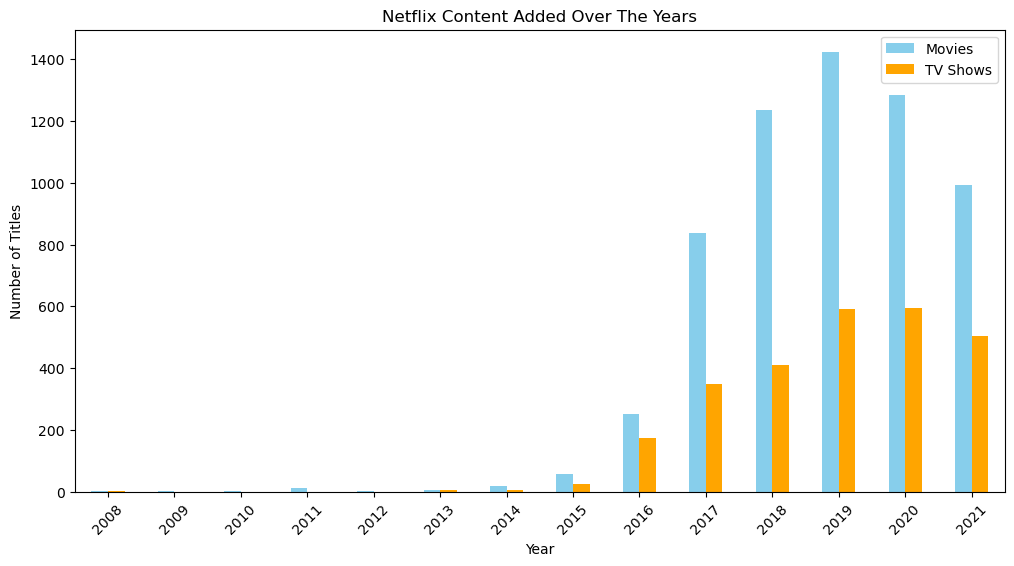

In [81]:
plt.figure(figsize=(12,6))
yearly_type.plot(kind='bar', figsize=(12,6), color=['skyblue', 'orange'])
plt.title('Netflix Content Added Over The Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend(['Movies', 'TV Shows'])
plt.xticks(rotation=45)
plt.show()

# check which genre is growing

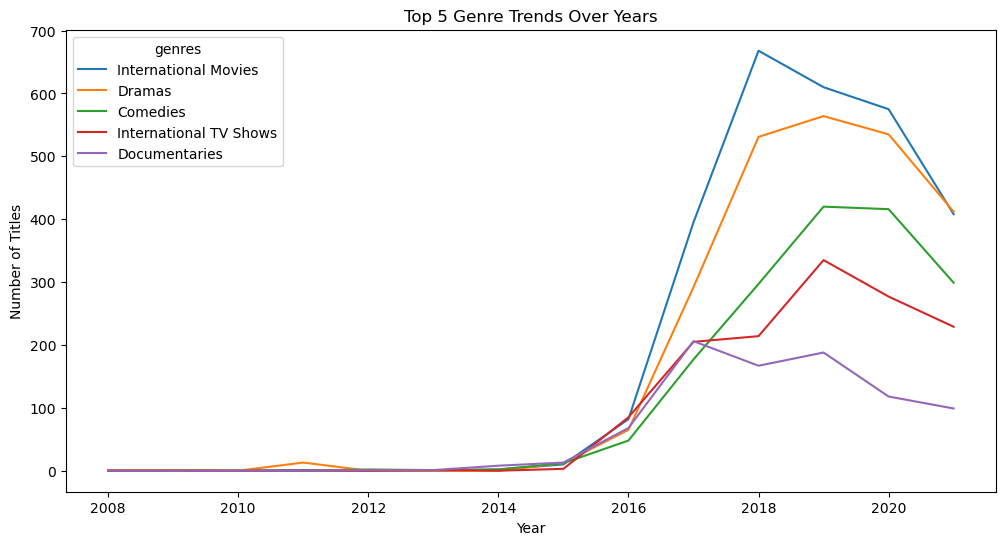

In [ ]:
data['genres'] = data['listed_in'].apply(lambda x: x.split(', '))
genre_year = data.explode('genres').groupby(['year_added', 'genres']).size().unstack().fillna(0)
#Pandas way — each item gets its own row
# top 5 genres over years
top5_genres = genre_counts.head(5).index
genre_year[top5_genres].plot(figsize=(12,6))
plt.title('Top 5 Genre Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

In [77]:
print("=== Netflix Content Analysis ===")
print(f"Total Titles: {len(data)}")
print(f"Year Range: {data['year_added'].min()} to {data['year_added'].max()}")
print(f"Peak Year: {data['year_added'].value_counts().idxmax()}")
print(f"Most Common Genre: {genre_counts.index[0]}")
print(f"Most Common Rating: {data['rating'].value_counts().idxmax()}")

=== Netflix Content Analysis ===
Total Titles: 8790
Year Range: 2008 to 2021
Peak Year: 2019
Most Common Genre: International Movies
Most Common Rating: TV-MA
